# 08b: Gradient-free MCMC — CF-RWMH vs NN-RWMH vs NN-RAM

Three-way A/B to attribute the mixing problem we've seen on the NN-surrogate path. All three runs share the same observed panel, same `RW_STEP_SIZE`, same chains × warmup × samples budget, and the same EKF likelihood form — only the policy plugged into the EKF and the sampler change.

- **CF-RWMH** (control): vanilla scalar RW-MH with the **closed-form analytical policy** (no NN). Same data, exact likelihood. Isolates the sampler from any surrogate-induced artifacts.
- **NN-RWMH**: same vanilla RW-MH, but the EKF uses the cached SHAC NN as its policy. Difference vs CF-RWMH attributes to NN approximation error.
- **NN-RAM** (Vihola 2012): same NN-surrogate spec, but RW-MH replaced by RAM (initial Cholesky `S₀ = RW_STEP_SIZE × I`, Robbins-Monro rank-1 updates during warmup). Difference vs NN-RWMH attributes to RAM's adaptation.

Possible diagnostic outcomes:

| CF-RWMH | NN-RWMH | NN-RAM | Reading |
|---|---|---|---|
| converges | converges | converges | All work; need more iters |
| converges | fails | fails | NN-induced artifacts |
| fails | fails | fails | RW-MH structurally inadequate on this 7D κ(α)+μ_ξ geometry |

| Profile | chains × N × T | iters (warmup + samples) | Wall (M1 CPU, all three methods) |
|---|---|---|---|
| SMOKE | 4 × 80 × 15  | 2000 + 500    | ~6-8 min  |
| BASE  | 4 × 100 × 15 | 10000 + 3000  | ~20-25 min |

Output dir: `outputs/notebooks/08b_rwmh_three_way_baseline/{MODE}/`. Loads bundle from 08a (`outputs/notebooks/08a_pretrain_nn_surrogate/shac_full_frictionless.*`).


In [ ]:
from pathlib import Path
from dataclasses import replace
import json
import os
import sys
import time
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
warnings.filterwarnings("ignore", message=r".*does not produce the same series as CPU implementation.*")
warnings.filterwarnings("ignore", message=r".*casting an input of type complex64.*")

_REPO_ROOT = None
for _rr_candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_rr_candidate / "src" / "v2").exists():
        _REPO_ROOT = _rr_candidate
        break
if _REPO_ROOT is None:
    import importlib.util as _rr_ilu
    _rr_spec = _rr_ilu.find_spec("src.v2")
    if _rr_spec is not None and _rr_spec.origin is not None:
        _REPO_ROOT = Path(_rr_spec.origin).resolve().parents[2]
if _REPO_ROOT is None:
    raise RuntimeError("Could not find repo root containing src/v2.")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from IPython.display import display

import tensorflow as tf
tf.config.set_visible_devices([], "GPU")
tf.get_logger().setLevel("ERROR")

from src.v2.environments.basic_investment import EconomicParams, ShockParams
from src.v2.environments.parameterized_basic_investment import ParameterizedBasicInvestmentEnv
from src.v2.estimation import BayesianRunConfig, SamplerKind, run_mcmc
from src.v2.estimation.bayesian_basic_investment import (
    load_policy_with_normalizer,
    make_closed_form_bayesian_spec,
    make_neural_bayesian_spec,
)
from src.v2.networks.policy import ParameterizedPolicyNetwork
from src.v2.utils.seeding import fold_in_seed

np.set_printoptions(precision=4, suppress=True)

BUNDLE_BASE = _REPO_ROOT / "outputs" / "notebooks" / "08a_pretrain_nn_surrogate" / "shac_full_frictionless"
meta = json.loads(BUNDLE_BASE.with_suffix(".meta.json").read_text())
panel_full = dict(np.load(BUNDLE_BASE.with_suffix(".panel.npz")))

param_env = ParameterizedBasicInvestmentEnv(
    nominal_econ=EconomicParams(**meta["env"]["nominal_econ"]),
    nominal_shocks=ShockParams(**meta["env"]["nominal_shocks"]),
    bounds=meta["env"]["bounds"],
)
policy_nn = ParameterizedPolicyNetwork(
    state_dim=param_env.state_dim(), action_dim=param_env.action_dim(), beta_dim=5,
    **param_env.action_spec(),
    n_layers=meta["nn_architecture"]["n_layers"],
    n_neurons=meta["nn_architecture"]["n_neurons"], seed=(202, 0),
)
policy_nn(tf.zeros((1, param_env.state_dim())), tf.zeros((1, 5)))
load_policy_with_normalizer(policy_nn, BUNDLE_BASE.with_suffix(".weights.h5"))
policy_nn.trainable = False

beta_true   = meta["ground_truth_beta"]
MASTER_SEED = tuple(meta["master_seed"])
OUTPUT_DIR  = _REPO_ROOT / "outputs" / "notebooks" / "08b_rwmh_three_way_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Bundle loaded; β_true = {beta_true}")

## Section 1: Spec, observed panel, step size

NN-surrogate spec from the standard factory. `RW_STEP_SIZE = 0.1` (a single scalar) drives both samplers: RW-MH uses it as the fixed proposal std on every parameter, RAM uses it as the diagonal of its initial Cholesky `S₀`. No per-axis or pilot calibration — the same scalar that would be a reasonable rough first guess if no prior information were available.


In [2]:
MODE = "LARGE"   # SMOKE | BASE | LARGE
PROFILES = {
    "SMOKE": dict(n_chains=4, n_warmup=5000, n_samples=500,  n_firms=50,  horizon=15),
    "BASE":   dict(n_chains=4, n_warmup=20000, n_samples=3000, n_firms=100, horizon=15),
    "LARGE":   dict(n_chains=4, n_warmup=40000, n_samples=3000, n_firms=200, horizon=15),
}
P       = PROFILES[MODE]
RUN_DIR = OUTPUT_DIR / MODE
RUN_DIR.mkdir(parents=True, exist_ok=True)

spec_nuts = make_neural_bayesian_spec(param_env, policy_nn)
N_slice, T_slice = int(P["n_firms"]), int(P["horizon"])
observed = {
    "y":          panel_full["y"][:N_slice,          :T_slice, np.newaxis].astype(np.float32),
    "log_k":      panel_full["log_k"][:N_slice,      :T_slice, np.newaxis].astype(np.float32),
    "log_k_next": panel_full["log_k_next"][:N_slice, :T_slice, np.newaxis].astype(np.float32),
}

# Single scalar proposal std applied isotropically to every unconstrained
# coordinate.  RW-MH freezes this at every step; RAM uses it as S₀ diagonal
# and adapts during warmup.
RW_STEP_SIZE = 0.01

print(f"MODE = {MODE}; {P['n_chains']} chains × ({P['n_warmup']} warmup + {P['n_samples']} samples) × {N_slice} × {T_slice}")
print(f"RW_STEP_SIZE = {RW_STEP_SIZE}")

MODE = LARGE; 4 chains × (40000 warmup + 3000 samples) × 200 × 15
RW_STEP_SIZE = 0.01


## Section 2: RW-MH (CF and NN)

Vanilla RW-MH with scalar `RW_STEP_SIZE` on two specs: the closed-form policy (CF, control) and the cached SHAC NN (NN, test). Same config, same data, different policy in the EKF. Distinct seed tokens so the proposal-noise sequences are independent.


In [3]:
spec_cf_rwmh = replace(make_closed_form_bayesian_spec(param_env), sampler_kind=SamplerKind.RW_MH)
cfg_cf_rwmh = BayesianRunConfig(
    n_chains=P["n_chains"], n_warmup=P["n_warmup"], n_samples=P["n_samples"],
    master_seed=tuple(MASTER_SEED),
    rw_step_size=RW_STEP_SIZE,
)
t0 = time.time()
result_cf_rwmh = run_mcmc(spec_cf_rwmh, observed, cfg_cf_rwmh,
                          seed=tuple(fold_in_seed(MASTER_SEED, "cf_rwmh")))
wall_cf_rwmh = time.time() - t0
print(f"CF-RWMH: wall = {wall_cf_rwmh:.1f}s; acceptance = {result_cf_rwmh.acceptance_rate:.3f}")

I0000 00:00:1779837205.891945 5842080 service.cc:145] XLA service 0x160f4a710 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779837205.891966 5842080 service.cc:153]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1779837208.063823 5842080 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


CF-RWMH: wall = 29.8s; acceptance = 0.101


In [4]:
spec_rwmh = replace(spec_nuts, sampler_kind=SamplerKind.RW_MH)
cfg_rwmh = BayesianRunConfig(
    n_chains=P["n_chains"], n_warmup=P["n_warmup"], n_samples=P["n_samples"],
    master_seed=tuple(MASTER_SEED),
    rw_step_size=RW_STEP_SIZE,
)
t0 = time.time()
result_rwmh = run_mcmc(spec_rwmh, observed, cfg_rwmh,
                       seed=tuple(fold_in_seed(MASTER_SEED, "rwmh")))
wall_rwmh = time.time() - t0
print(f"RW-MH: wall = {wall_rwmh:.1f}s; acceptance = {result_rwmh.acceptance_rate:.3f}")

RW-MH: wall = 2991.2s; acceptance = 0.102


## Section 3: RAM (Vihola 2012)

Starts from the same `RW_STEP_SIZE × I` Cholesky as RW-MH's fixed scale. During warmup, S Sᵀ is updated by rank-1 corrections coercing acceptance toward 0.234 and learning off-diagonal posterior structure; after warmup, S is frozen.


In [5]:
spec_ram = replace(spec_nuts, sampler_kind=SamplerKind.RAM)
cfg_ram = BayesianRunConfig(
    n_chains=P["n_chains"], n_warmup=P["n_warmup"], n_samples=P["n_samples"],
    master_seed=tuple(MASTER_SEED),
    ram_initial_scale=RW_STEP_SIZE,
    ram_target_accept=0.234,
    ram_adaptation_decay=0.7,
)
t0 = time.time()
result_ram = run_mcmc(spec_ram, observed, cfg_ram,
                     seed=tuple(fold_in_seed(MASTER_SEED, "ram")))
wall_ram = time.time() - t0
print(f"RAM:   wall = {wall_ram:.1f}s; warmup-acceptance = {result_ram.metadata['ram_warmup_acceptance']:.3f}; "
      f"post-warmup acceptance = {result_ram.acceptance_rate:.3f}")

RAM:   wall = 3158.6s; warmup-acceptance = 0.064; post-warmup acceptance = 0.077


## Section 4: Comparison


In [6]:
def _summary(result, parameter_names, beta_true):
    rows = []
    for name in parameter_names:
        s = np.asarray(result.posterior_samples[name]).reshape(-1)
        rows.append({
            "parameter": name,
            "true":      beta_true[name],
            "median":    float(np.median(s)),
            "ci_2.5":    float(np.quantile(s, 0.025)),
            "ci_97.5":   float(np.quantile(s, 0.975)),
            "r_hat":     float(result.r_hat[name]),
            "ess":       float(result.ess[name]),
        })
    return pd.DataFrame(rows)

summary_cf_rwmh = _summary(result_cf_rwmh, spec_nuts.parameter_names, beta_true)
summary_rwmh    = _summary(result_rwmh,    spec_nuts.parameter_names, beta_true)
summary_ram     = _summary(result_ram,     spec_nuts.parameter_names, beta_true)

summary_cf_rwmh.to_csv(RUN_DIR / "cf_rwmh_summary.csv", index=False)
summary_rwmh.to_csv(   RUN_DIR / "rwmh_summary.csv",    index=False)
summary_ram.to_csv(    RUN_DIR / "ram_summary.csv",     index=False)
np.savez(RUN_DIR / "cf_rwmh_samples.npz", **{k: np.asarray(result_cf_rwmh.posterior_samples[k])
                                             for k in spec_nuts.parameter_names})
np.savez(RUN_DIR / "rwmh_samples.npz",    **{k: np.asarray(result_rwmh.posterior_samples[k])
                                             for k in spec_nuts.parameter_names})
np.savez(RUN_DIR / "ram_samples.npz",     **{k: np.asarray(result_ram.posterior_samples[k])
                                             for k in spec_nuts.parameter_names})

def _headline(name, result, wall):
    mean_ess = float(np.mean([result.ess[k] for k in spec_nuts.parameter_names]))
    min_ess  = float(np.min ([result.ess[k] for k in spec_nuts.parameter_names]))
    max_rhat = float(np.max ([result.r_hat[k] for k in spec_nuts.parameter_names]))
    return {
        "method":      name,
        "wall_sec":    round(wall, 1),
        "accept":      round(result.acceptance_rate, 3),
        "mean_ess":    round(mean_ess, 1),
        "min_ess":     round(min_ess,  1),
        "max_rhat":    round(max_rhat, 3),
        "ess_per_sec": round(mean_ess / wall, 3),
    }
headline = pd.DataFrame([
    _headline("CF-RWMH", result_cf_rwmh, wall_cf_rwmh),
    _headline("NN-RWMH", result_rwmh,    wall_rwmh),
    _headline("NN-RAM",  result_ram,     wall_ram),
])

print("CF-RWMH posterior summary:")
display(summary_cf_rwmh)
print("\nNN-RWMH posterior summary:")
display(summary_rwmh)
print("\nNN-RAM posterior summary:")
display(summary_ram)
print("\nHeadline comparison:")
display(headline)
headline.to_csv(RUN_DIR / "headline.csv", index=False)

CF-RWMH posterior summary:


,parameter,true,median,ci_2.5,ci_97.5,r_hat,ess
0,alpha,0.50,0.495944,0.487202,0.833662,4700.093750,25.322670
1,rho,0.50,0.500361,0.101165,0.509224,5764.871094,38.096443
2,sigma_epsilon,0.24,0.232460,0.225547,0.240436,1.506287,59.196281
3,production_mean,0.05,0.051616,-0.789033,0.081593,1951.059448,44.010479
4,production_std,0.05,0.047042,0.033222,0.054387,17.239246,25.906124
5,investment_mean,-0.10,-0.067086,-1.217667,0.011626,780.375732,378.099823
6,investment_std,0.05,0.053073,0.045322,0.279875,2681.411377,138.126251



NN-RWMH posterior summary:


,parameter,true,median,ci_2.5,ci_97.5,r_hat,ess
0,alpha,0.50,0.546716,0.534017,0.846240,4138.439453,23.304714
1,rho,0.50,0.481210,0.102553,0.496180,2394.468262,24.981785
2,sigma_epsilon,0.24,0.235039,0.228987,0.241656,1.256512,64.801620
3,production_mean,0.05,-0.073056,-0.824164,-0.034467,2015.211304,269.584778
4,production_std,0.05,0.035952,0.015223,0.051838,185.137939,28.843311
5,investment_mean,-0.10,-0.527753,-1.219032,-0.406391,250.371460,346.550598
6,investment_std,0.05,0.060211,0.047800,0.280091,3691.473145,142.128082



NN-RAM posterior summary:


,parameter,true,median,ci_2.5,ci_97.5,r_hat,ess
0,alpha,0.50,0.458979,0.375833,0.556603,1669.835327,26.472546
1,rho,0.50,0.395697,0.314865,0.487447,604.403748,25.543043
2,sigma_epsilon,0.24,0.238514,0.227318,0.247855,7.876586,38.841843
3,production_mean,0.05,0.140864,-0.100892,0.351459,767.691711,56.391495
4,production_std,0.05,0.038894,0.030212,0.051439,39.616539,26.579584
5,investment_mean,-0.10,0.210127,-0.627578,0.917400,1204.136963,37.249222
6,investment_std,0.05,0.063041,0.048730,0.070658,55.326633,40.170868



Headline comparison:


,method,wall_sec,accept,mean_ess,min_ess,max_rhat,ess_per_sec
0,CF-RWMH,29.8,0.101,101.3,25.3,5764.871,3.400
1,NN-RWMH,2991.2,0.102,128.6,23.3,4138.439,0.043
2,NN-RAM,3158.6,0.077,35.9,25.5,1669.835,0.011


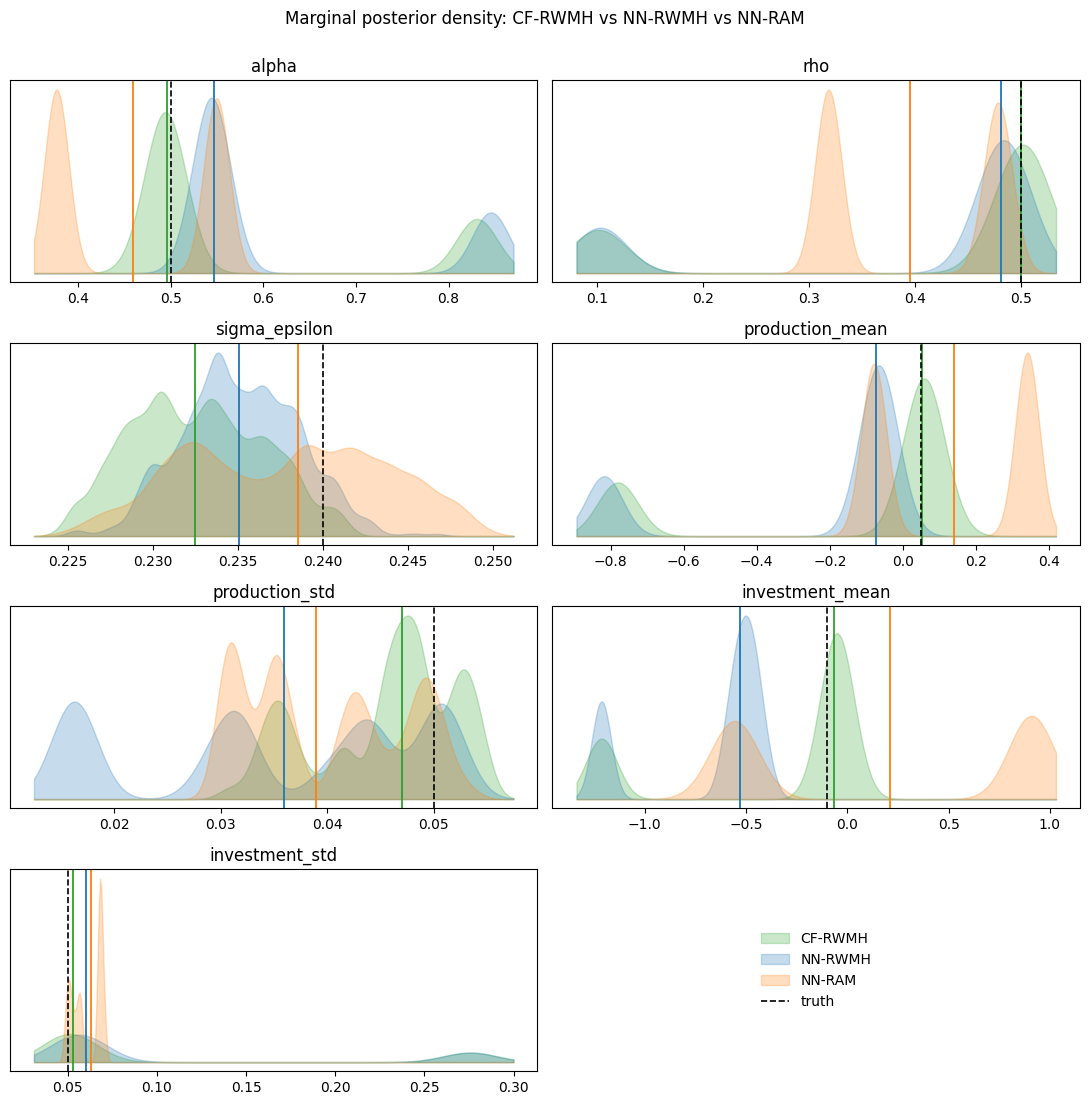

In [7]:
# Marginal posterior density overlay (bayesplot-style mcmc_dens_overlay).
# Three KDEs per parameter (CF-RWMH, NN-RWMH, NN-RAM) + vertical medians + truth.
METHODS = [
    ("CF-RWMH", result_cf_rwmh, "C2"),
    ("NN-RWMH", result_rwmh,    "C0"),
    ("NN-RAM",  result_ram,     "C1"),
]
fig, axes = plt.subplots(4, 2, figsize=(11, 11))
axes = axes.flatten()
for ax, name in zip(axes, spec_nuts.parameter_names):
    samples = {label: np.asarray(r.posterior_samples[name]).reshape(-1) for label, r, _ in METHODS}
    lo = min(min(s.min() for s in samples.values()), beta_true[name])
    hi = max(max(s.max() for s in samples.values()), beta_true[name])
    pad = 0.05 * (hi - lo) if hi > lo else 0.01
    xs = np.linspace(lo - pad, hi + pad, 400)
    for label, _, color in METHODS:
        ax.fill_between(xs, gaussian_kde(samples[label])(xs), alpha=0.25, color=color, label=label)
        ax.axvline(np.median(samples[label]), color=color, lw=1.3)
    ax.axvline(beta_true[name], color="k", ls="--", lw=1.2, label="truth")
    ax.set_title(name); ax.set_yticks([])

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes[len(spec_nuts.parameter_names):]:
    ax.axis("off")
axes[len(spec_nuts.parameter_names)].legend(
    handles, labels, loc="center", fontsize=10, frameon=False,
)

fig.suptitle("Marginal posterior density: CF-RWMH vs NN-RWMH vs NN-RAM", fontsize=12, y=1.00)
fig.tight_layout()
fig.savefig(RUN_DIR / "density_overlay.png", dpi=120, bbox_inches="tight")
plt.show()

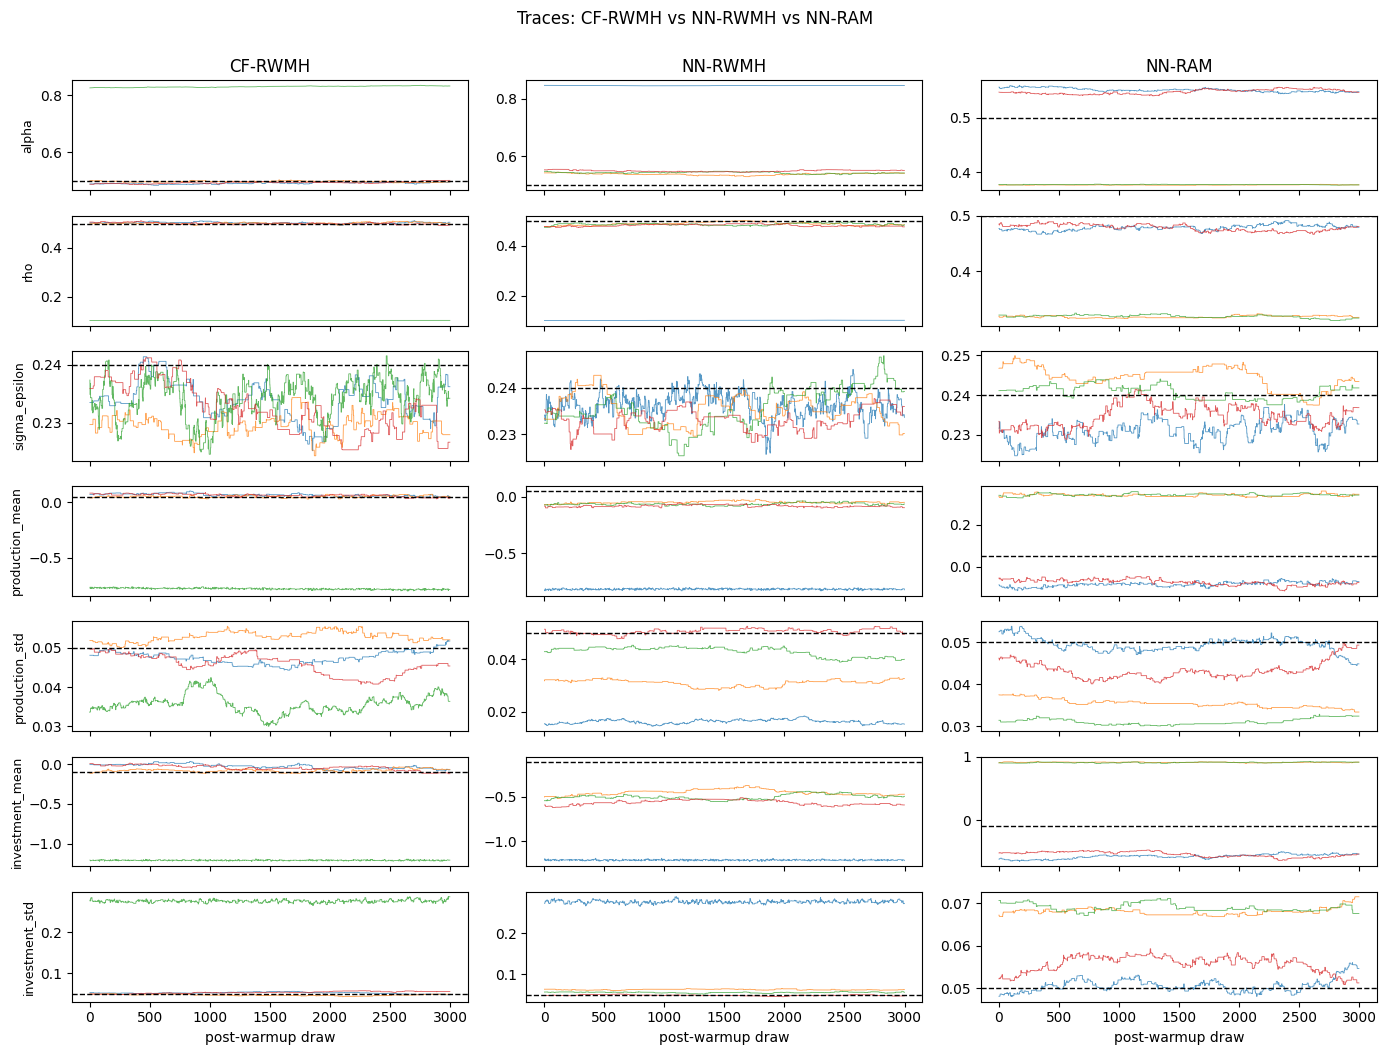

In [8]:
# Trace plot per parameter, three columns (CF-RWMH | NN-RWMH | NN-RAM), one row per parameter.
n_params = len(spec_nuts.parameter_names)
fig, axes = plt.subplots(n_params, 3, figsize=(14, 1.5 * n_params), sharex=True)
for i, name in enumerate(spec_nuts.parameter_names):
    for j, (label, result) in enumerate([
        ("CF-RWMH", result_cf_rwmh),
        ("NN-RWMH", result_rwmh),
        ("NN-RAM",  result_ram),
    ]):
        s = np.asarray(result.posterior_samples[name])   # (n_samples, n_chains)
        for c in range(s.shape[1]):
            axes[i, j].plot(s[:, c], lw=0.6, alpha=0.75)
        axes[i, j].axhline(beta_true[name], color="k", ls="--", lw=1.0)
        if i == 0:
            axes[i, j].set_title(label)
        if j == 0:
            axes[i, j].set_ylabel(name, fontsize=9)
for j in range(3):
    axes[-1, j].set_xlabel("post-warmup draw")
fig.suptitle("Traces: CF-RWMH vs NN-RWMH vs NN-RAM", fontsize=12, y=1.00)
fig.tight_layout()
fig.savefig(RUN_DIR / "trace.png", dpi=120, bbox_inches="tight")
plt.show()